In [2]:
import sys
lib_path = [r'C:\Users\ikahbasi\OneDrive\Applications\GitHub\SeisRoutine',
            r'C:\Users\ikahb\OneDrive\Applications\GitHub\SeisRoutine']
for path in lib_path:
    sys.path.append(path)
##########################################################################
import SeisRoutine.catalog as src
import SeisRoutine.waveform as srw
import SeisRoutine.config as srconf
import SeisRoutine.statistics as srs
##########################################################################
import myfuncs as mf

In [3]:
import seisbench.generate as sbg
import seisbench.models as sbm
import torch
from tqdm import tqdm
from scipy import signal
import os
import seisbench.data as sbd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label
import pandas as pd
import logging

# Classes and Functions

In [4]:
class Tapering:
    def __init__(self, alpha=0.3, key='X'):
        self.alpha = alpha  # Tapering Coefficient
        if isinstance(key, str):
            self.key = (key, key)
        else:
            self.key = key

    def __call__(self, state_dict):
        x, metadata = state_dict[self.key[0]]
        taper = signal.windows.tukey(x.shape[-1], self.alpha)
        x = x * taper
        state_dict[self.key[1]] = (x, metadata)

In [5]:
def find_peaks(data, treshold):
    mask = data > treshold
    labeled, num_features = label(mask)
    peaks = []
    for i in range(1, num_features + 1):
        segment_indices = np.where(labeled == i)[0]
        segment_values = data[segment_indices]
        max_index = np.argmax(segment_values)
        max_index_in_segment = segment_indices[max_index]
        peaks.append(max_index_in_segment)
    return peaks

# Loading DataSets

In [6]:
init_cfg = srconf.load_config('0-init-cfg.yml')
cfg_path = os.path.join(init_cfg.target_config_filepath,
                        init_cfg.target_config_filename)
cfg = srconf.load_config(cfg_path)

In [7]:
srconf.configure_logging(level=cfg.log.level,
                         log_format=cfg.log.format,
                         mode=cfg.log.mode, colored_console=True,
                         filepath=cfg.dataset.path,
                         filename_prefix=cfg.log.filename_prefix,
                         filename=cfg.log.filename)

Logging Starts in:
F:\DataSets-Local\AutoLabeling_on_Merged_datasets_2025-12-07_17-03-55.log


In [8]:
mf.resources.Check_CUDA_availability()
txt = mf.resources.get_cpu_info()
logging.info(txt)

2025-12-07 17:03:55 - INFO - CUDA available: True
2025-12-07 17:03:55 - INFO - CUDA device count: 1
2025-12-07 17:03:55 - INFO - Current device index: 0
2025-12-07 17:03:55 - INFO - Current device name: NVIDIA GeForce GTX 1650
2025-12-07 17:03:55 - INFO - 
=== Device Properties ===
2025-12-07 17:03:55 - INFO - Name: NVIDIA GeForce GTX 1650
2025-12-07 17:03:55 - INFO - Total memory (GB): 4.00
2025-12-07 17:03:55 - INFO - Multiprocessors: 14
2025-12-07 17:03:55 - INFO - Compute capability: 7.5
2025-12-07 17:03:55 - INFO - Max threads per block: N/A
2025-12-07 17:03:55 - INFO - Max threads per multiprocessor: 1024
2025-12-07 17:03:55 - INFO - Shared memory per block (bytes): N/A
2025-12-07 17:03:55 - INFO - Warp size: 32
2025-12-07 17:03:55 - INFO - Clock rate (kHz): N/A
2025-12-07 17:03:55 - INFO - 
=== Memory Usage ===
2025-12-07 17:03:55 - INFO - Allocated (GB): 0.000
2025-12-07 17:03:55 - INFO - Reserved (GB): 0.000
2025-12-07 17:03:55 - INFO - 
=== nvidia-smi Output ===
2025-12-07 17

In [9]:
dataset = sbd.WaveformDataset(
    path=os.path.join(cfg.dataset.path, cfg.dataset.fname),
    sampling_rate=cfg.training.dataset.sampling_rate,
    component_order=cfg.training.dataset.component_order,
          )

In [17]:
sps = 100
augmentations = [
    Tapering(),
    # sbg.Filter(N=4,
    #            Wn=[0.5],
    #            btype='highpass',
    #            forward_backward=True,
    #            ),
    sbg.Normalize(
        demean_axis=-1,
        amp_norm_axis=-1,
        amp_norm_type="peak"),
    sbg.FixedWindow(
        p0=-15*sps,
        windowlen=1*60*sps,
        strategy="pad",
        key='X'),
    sbg.ChangeDtype(np.float32),
]
generator = sbg.GenericGenerator(dataset)
generator.add_augmentations(augmentations)

In [18]:
from torch.utils.data import DataLoader
from seisbench.util import worker_seeding

In [36]:
batch_size = 1024 * 5
num_workers = 0  # The number of threads used for loading data
dataloader = DataLoader(
    generator,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
)


# Loading Auto-Pickers

In [37]:
dl_pickers = {
    #'PhaseNet_stead': sbm.PhaseNet.from_pretrained("stead"),
    # 'PhaseNet_original': sbm.PhaseNet.from_pretrained("original"),
    #   'PhaseNet_scedc': sbm.PhaseNet.from_pretrained("scedc"),
    #   'PhaseNet_instance': sbm.PhaseNet.from_pretrained("instance"),
    ############################################################################
    'EQTransformer_stead': sbm.EQTransformer.from_pretrained("stead"),
    #   'EQTransformer_original': sbm.EQTransformer.from_pretrained("original"),
    #   'EQTransformer_scedc': sbm.EQTransformer.from_pretrained("scedc"),
    #   'EQTransformer_instance': sbm.EQTransformer.from_pretrained("instance"),
    ############################################################################
    #   sbm.GPD.from_pretrained("stead"),
    # 'GPD_original': sbm.GPD.from_pretrained("original"),
    #   'GPD_scedc': sbm.GPD.from_pretrained("scedc"),
    #   'GPD_instance': sbm.GPD.from_pretrained("instance"),
}

if torch.cuda.is_available():
    for key, dl_picker in dl_pickers.items():
        dl_picker.cuda();
        logging.info(f"{key} Running on GPU")
        logging.info(dl_picker._annotate_args.get("*_threshold"))
else:
    logging.info("Running on CPU")

2025-12-07 17:12:13 - INFO - EQTransformer_stead Running on GPU
2025-12-07 17:12:13 - INFO - ('Detection threshold for the provided phase', 0.1)


# Run

In [38]:
metadata = dataset.metadata.copy()

In [39]:
# lst = []
# for ii in tqdm(range(len(metadata))):
#     data = generator[ii]
#     data_X = data['X']
#     lst.append(data_X.shape)
# for index, el in enumerate(lst):
#     if el != (3, 3001):
#         print(f'{el=}\t{index=}\t{lst.count(el)=}')

In [40]:
for batch_id, batch in enumerate(dataloader):
    print(batch_id)
    break

0


In [41]:
batch['X'].shape

torch.Size([5120, 3, 6000])

In [46]:
x = torch.tensor(batch['X']).to(dl_picker.device)#.unsqueeze(0)
annotated = dl_picker.annotate_batch_pre(x, {})

C:\Users\ikahbasi\AppData\Local\Temp\ipykernel_5204\3009020752.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(batch['X']).to(dl_picker.device)#.unsqueeze(0)


In [54]:
annotated

tensor([[[ 0.0000e+00,  3.0356e-11,  1.0983e-10,  ...,  1.0983e-10,
           3.0356e-11,  0.0000e+00],
         [-0.0000e+00, -7.5890e-12, -2.7457e-11,  ..., -2.7457e-11,
          -7.5890e-12, -0.0000e+00],
         [-0.0000e+00, -7.5890e-12, -2.7457e-11,  ..., -2.7457e-11,
          -7.5890e-12, -0.0000e+00]],

        [[ 0.0000e+00,  1.7075e-11,  6.1779e-11,  ...,  6.1779e-11,
           1.7075e-11,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00]],

        [[-0.0000e+00, -7.5890e-12, -2.7457e-11,  ..., -2.7457e-11,
          -7.5890e-12, -0.0000e+00],
         [ 0.0000e+00,  2.6561e-11,  9.6100e-11,  ...,  9.6100e-11,
           2.6561e-11,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00]],

        ...,

        [[-0.0000e+00, -4.5534e-11,

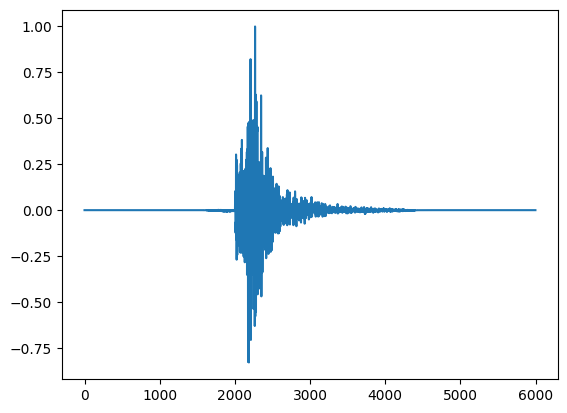

In [60]:
plt.plot(annotated[2][2].cpu().T)

In [ ]:
p_peaks = find_peaks(annotated[1], treshold=treshold)

torch.Size([5120, 3, 6000])

In [35]:
annotated[0]

tensor([[-0.0000e+00, -3.0356e-11, -1.0983e-10,  ..., -1.0983e-10,
         -3.0356e-11, -0.0000e+00],
        [-0.0000e+00, -6.0712e-11, -2.1966e-10,  ..., -2.1966e-10,
         -6.0712e-11, -0.0000e+00],
        [ 0.0000e+00,  3.7945e-12,  1.3729e-11,  ...,  1.3729e-11,
          3.7945e-12,  0.0000e+00]], device='cuda:0')

In [ ]:
for key, dl_picker in dl_pickers.items():
    treshold = dl_picker._annotate_args.get("*_threshold")[1]
    for ii in tqdm(range(len(metadata))):
        data = generator[ii]
        data_X0 = data['X']
        if data_X0.shape != (3, 3001):
            continue
        data_X = torch.tensor(data_X0, device=dl_picker.device).unsqueeze(0)
        # logging.info(f'{ii}, {key}')
        with torch.no_grad():
            pred = dl_picker(data_X)
            pred = pred.cpu().detach().numpy().squeeze()
        p_peaks = find_peaks(pred[1], treshold=treshold)
        s_peaks = find_peaks(pred[2], treshold=treshold)
        # print(p_peaks, s_peaks)
        metadata.at[ii, f'trace_P_{key}-AutoPik'] = p_peaks
        metadata.at[ii, f'trace_S_{key}-AutoPik'] = s_peaks
path = os.path.join(cfg.dataset.path, 'metadata-with-AutoPicks.pkl')
metadata.to_pickle(path)

In [ ]:
for key, model in dl_pickers.items():
    for phase in ['P', 'S']:
        metadata[f'trace_{phase}_{key}-AutoPik'] = None  # or object
        metadata = metadata.astype({f'trace_{phase}_{key}-AutoPik': 'object'}, copy=False)

for ii in tqdm(range(len(metadata))):
    data = generator[ii]
    data_X0 = data['X']
    if data_X0.shape != (3, 3001):
        continue
    
    # plt.plot(data_X.T); plt.show()
    for key, dl_picker in dl_pickers.items():
        data_X = torch.tensor(data_X0, device=dl_picker.device).unsqueeze(0)
        # logging.info(f'{ii}, {key}')
        with torch.no_grad():
            pred = dl_picker(data_X)
            pred = pred.cpu().detach().numpy().squeeze()
        treshold = dl_picker._annotate_args.get("*_threshold")[1]
        p_peaks = find_peaks(pred[1], treshold=treshold)
        s_peaks = find_peaks(pred[2], treshold=treshold)
        # print(p_peaks, s_peaks)
        metadata.at[ii, f'trace_P_{key}-AutoPik'] = p_peaks
        metadata.at[ii, f'trace_S_{key}-AutoPik'] = s_peaks
        #
        # plt.plot(pred.T[:, 1:]); plt.legend([_ for _ in 'PS'])
        # plt.vlines(p_peaks, ymin=0, ymax=1, colors='red')
        # plt.vlines(s_peaks, ymin=0, ymax=1, colors='blue')
        # results[key] = pred
    # plt.show()
    # if ii == 1:
    #     break
path = os.path.join(cfg.dataset.path, 'metadata-with-AutoPicks.pkl')
metadata.to_pickle(path)

C:\Users\ikahbasi\AppData\Local\Temp\ipykernel_3796\3970249636.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metadata[f'trace_{phase}_{key}-AutoPik'] = None  # or object
  0%|          | 0/81014 [00:00<?, ?it/s]


AssertionError: 